In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("task1_dataset.csv")

In [4]:
df.isna().sum()

date                 0
age                  0
income              80
loan_amount         80
credit_score        80
num_transactions     0
annual_spend        80
city                 0
employment_type      0
loan_type            0
target               0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              2000 non-null   object 
 1   age               2000 non-null   int64  
 2   income            1920 non-null   float64
 3   loan_amount       1920 non-null   float64
 4   credit_score      1920 non-null   float64
 5   num_transactions  2000 non-null   int64  
 6   annual_spend      1920 non-null   float64
 7   city              2000 non-null   object 
 8   employment_type   2000 non-null   object 
 9   loan_type         2000 non-null   object 
 10  target            2000 non-null   float64
dtypes: float64(5), int64(2), object(4)
memory usage: 172.0+ KB


In [5]:
df.describe()

,age,income,loan_amount,credit_score,num_transactions,annual_spend,target
count,2000.000000,1920.000000,1.920000e+03,1920.000000,2000.00000,1.920000e+03,2000.000000
mean,43.569500,64111.180976,3.135794e+05,649.451886,30.13600,1.081605e+06,246455.466965
std,14.892786,35334.616365,1.415505e+05,80.483534,5.24006,7.028877e+05,66306.121409
min,18.000000,-5135.359342,-2.336766e+04,373.096400,14.00000,-1.461650e+05,13300.170171
25%,31.000000,46943.316170,2.337310e+05,594.475126,27.00000,7.887255e+05,201830.604797
50%,43.000000,60602.715999,3.041103e+05,649.578439,30.00000,1.004297e+06,245424.498558
75%,56.000000,75294.080356,3.722464e+05,703.239833,33.00000,1.214651e+06,292110.550126
max,69.000000,426093.266439,1.525158e+06,919.903709,52.00000,7.541094e+06,478502.472525


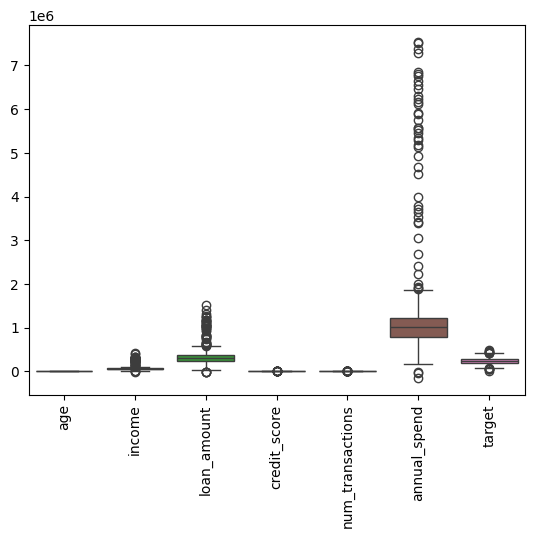

In [9]:
sns.boxplot(df)
plt.xticks(rotation=90)
plt.show()

In [11]:
med=df['income'].median()
df["income"]=df["income"].fillna(med)
df["income"].isna().sum()

np.int64(0)

In [ ]:
med=df['loan_amount'].median()
df["loan_amount"]=df["loan_amount"].fillna(med)
df["loan_amount"].isna().sum()

np.int64(0)

In [13]:
med=df['credit_score'].median()
df["credit_score"]=df["credit_score"].fillna(med)
df["credit_score"].isna().sum()

np.int64(0)

In [14]:
med=df['annual_spend'].median()
df["annual_spend"]=df["annual_spend"].fillna(med)
df["annual_spend"].isna().sum()

np.int64(0)

In [15]:
df.isna().sum()

date                0
age                 0
income              0
loan_amount         0
credit_score        0
num_transactions    0
annual_spend        0
city                0
employment_type     0
loan_type           0
target              0
dtype: int64

In [16]:
# use clip method to handle outliers in income column
def cap_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower_bound, upper_bound)

cap_outliers('income')
cap_outliers('loan_amount')
cap_outliers('credit_score')
cap_outliers('annual_spend')
cap_outliers('num_transactions')
cap_outliers('target')

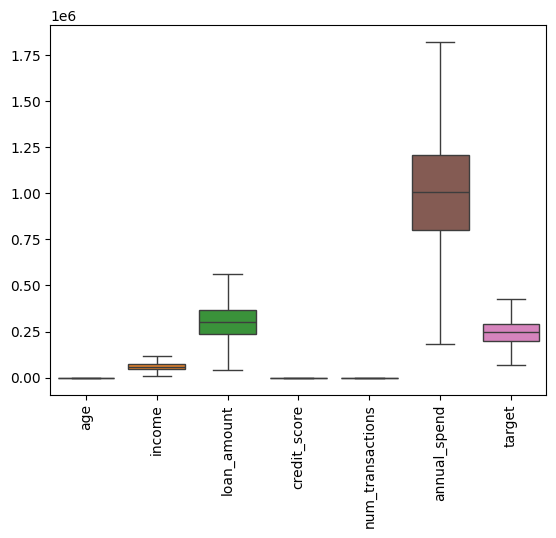

In [17]:
sns.boxplot(df)
plt.xticks(rotation=90)
plt.show()

In [20]:
df['date']=pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              2000 non-null   datetime64[ns]
 1   age               2000 non-null   int64         
 2   income            2000 non-null   float64       
 3   loan_amount       2000 non-null   float64       
 4   credit_score      2000 non-null   float64       
 5   num_transactions  2000 non-null   int64         
 6   annual_spend      2000 non-null   float64       
 7   city              2000 non-null   object        
 8   employment_type   2000 non-null   object        
 9   loan_type         2000 non-null   object        
 10  target            2000 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2), object(3)
memory usage: 172.0+ KB


In [ ]:
# Convering ordinal columns into numerical using One Hot Encoding
cat=['city','employment_type','loan_type']
from sklearn.preprocessing import OneHotEncoder

encoded=OneHotEncoder(sparse_output=False)
encoded_data=encoded.fit_transform(df[cat])
encoded_df=pd.DataFrame(encoded_data,columns=encoded.get_feature_names_out(cat))
encoded_df


In [22]:
df=pd.concat([df.drop(columns=cat),encoded_df],axis=1)

In [36]:
df['date'] = pd.to_datetime(df['date'])
df['date'] = df['date'].astype('int64')

In [38]:
df.dtypes

date                               int64
age                                int64
income                           float64
loan_amount                      float64
credit_score                     float64
num_transactions                   int64
annual_spend                     float64
target                           float64
city_Bangalore                   float64
city_Chennai                     float64
city_Delhi                       float64
city_Hyderabad                   float64
city_Mumbai                      float64
employment_type_Salaried         float64
employment_type_Self-Employed    float64
employment_type_Student          float64
employment_type_Unemployed       float64
loan_type_Auto                   float64
loan_type_Education              float64
loan_type_Home                   float64
loan_type_Personal               float64
dtype: object

In [39]:
# Model 2:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Split features & target
X = df.drop(columns='target', axis=1)
y = df['target']

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create Model
model = LinearRegression()

# 4. Train Model
model.fit(X_train, y_train)

# 5. Predict
y_pred = model.predict(X_test)

# 6. Evaluation (IMPORTANT)
print("R2 Score (Accuracy-like):", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score (Accuracy-like): 0.40138653935550483
MAE: 40518.691673663634
MSE: 2671989828.99379
